# 07 · Linear viscoelasticity

Bread dough stretches and partly springs back; a polymer part under constant load slowly creeps; a
rubber band relaxes. Such materials combine elastic storage with viscous flow. In the linear range
(small deformations) their behaviour is fully described by one material function - the relaxation
modulus $G(t)$ or, equivalently, the creep compliance $J(t)$ - and responses to any loading history follow
by superposition.

**What you will learn**
- describe creep and relaxation with spring-dashpot models
- fit a creep test and predict recovery by Boltzmann superposition
- separate elastic, delayed and permanent deformation
- convert a relaxation modulus into a creep compliance

**Before you start:** notebooks 01 and 03; exponential functions  ·  **Time:** about 60-75 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets
from engrheo import viscoelastic as ve
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Springs and dashpots
A spring stores energy (stress proportional to strain), a dashpot dissipates it (stress proportional to strain
rate). Combining them gives the classical models:

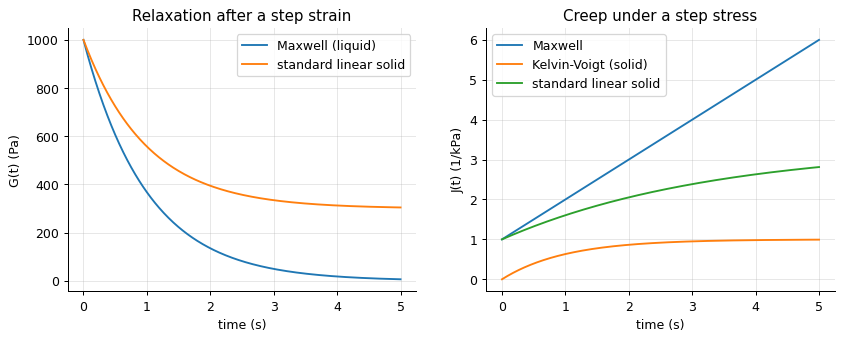

In [2]:
t = np.linspace(0, 5, 400)
mx, kv = ve.maxwell(1000.0, 1000.0), ve.kelvin_voigt(1000.0, 1000.0)
sls = ve.standard_linear_solid(300.0, 700.0, 1.0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(t, mx["relaxation"](t), label="Maxwell (liquid)"); a1.plot(t, sls["relaxation"](t), label="standard linear solid")
a1.set(xlabel="time (s)", ylabel="G(t) (Pa)", title="Relaxation after a step strain"); a1.legend()
a2.plot(t, mx["creep"](t) * 1e3, label="Maxwell"); a2.plot(t, kv["creep"](t) * 1e3, label="Kelvin-Voigt (solid)")
a2.plot(t, sls["creep"](t) * 1e3, label="standard linear solid")
a2.set(xlabel="time (s)", ylabel="J(t) (1/kPa)", title="Creep under a step stress"); a2.legend()
plt.show()

The Maxwell model relaxes completely and creeps without limit - a liquid. The Kelvin-Voigt model creeps to
a finite strain but cannot relax a step strain - a solid. The standard linear solid relaxes to a plateau.

## Bread dough: creep and recovery
A constant stress of 50 Pa was applied for 120 s and then removed:

fit to the creep phase only:
   G1    =      4450  +/-  62%
   eta1  = 5.165e+05  +/-  68%
   G2    =      1624  +/-  24%
   eta2  = 1.935e+04  +/-  59%
true values: G1 = 5000 Pa, eta1 = 1e6 Pa s, G2 = 2000 Pa, eta2 = 5e4 Pa s


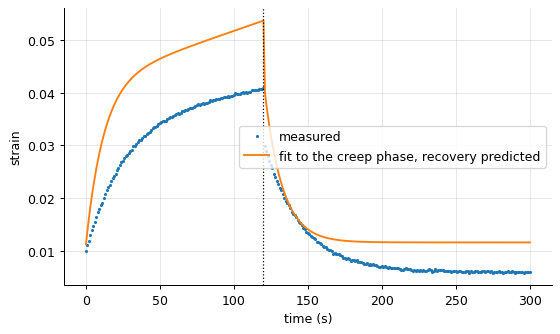

predicted permanent strain 0.0116; measured strain at 300 s: 0.0061


In [3]:
dough = pd.read_csv(datasets.path("dough_creep_recovery.csv"), comment="#")
tt, strain = dough.time_s.to_numpy(), dough.strain.to_numpy()
creep = tt <= 120
names = ["G1", "eta1", "G2", "eta2"]

def history(t, G1, eta1, G2, eta2):
    # Boltzmann: stress +50 Pa at t = 0 and -50 Pa at t = 120 s
    J = lambda s: np.where(s >= 0, ve.burgers_creep(np.maximum(s, 0), G1, eta1, G2, eta2), 0.0)
    return 50.0 * (J(t) - np.where(t > 120, J(t - 120), 0.0))

p_creep, cov_c = optimize.curve_fit(ve.burgers_creep, tt[creep], strain[creep] / 50, p0=[4e3, 5e5, 1e3, 1e4], bounds=(0, np.inf))
print("fit to the creep phase only:")
for n_, v, s_ in zip(names, p_creep, np.sqrt(np.diag(cov_c))):
    print(f"   {n_:<5} = {v:9.4g}  +/- {s_/v:4.0%}")
print("true values: G1 = 5000 Pa, eta1 = 1e6 Pa s, G2 = 2000 Pa, eta2 = 5e4 Pa s")
plt.plot(tt, strain, ".", ms=3, label="measured")
plt.plot(tt, history(tt, *p_creep), label="fit to the creep phase, recovery predicted")
plt.axvline(120, color="k", ls=":", lw=1); plt.xlabel("time (s)"); plt.ylabel("strain"); plt.legend(); plt.show()
print(f"predicted permanent strain {50*120/p_creep[1]:.4f}; measured strain at 300 s: {strain[-1]:.4f}")

The fit follows the creep curve closely - yet its parameters are uncertain by tens of percent, and the
predicted recovery is badly wrong: the model expects about twice as much permanent strain as the dough
shows. Over 120 s, slow delayed elasticity and genuine viscous flow produce nearly the same creep curve,
so the creep phase alone cannot tell them apart. The **recovery** phase can: delayed elasticity comes back,
viscous flow does not. Fitting the whole history with Boltzmann superposition (removing the stress is the
same as adding an opposite stress at 120 s) uses that information:

fit to creep and recovery together:
   G1    =      5000  +/-  0.3%
   eta1  =  9.99e+05  +/-  0.2%
   G2    =      2000  +/-  0.1%
   eta2  = 4.996e+04  +/-  0.3%
retardation time eta2/G2 = 25.0 s; permanent strain 0.0060 (measured 0.0061)


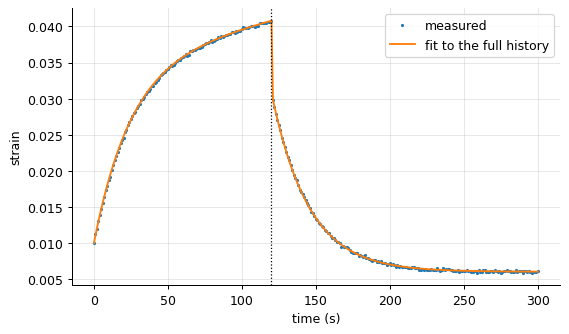

In [4]:
p_all, cov_a = optimize.curve_fit(history, tt, strain, p0=[4e3, 5e5, 1e3, 1e4], bounds=(0, np.inf))
print("fit to creep and recovery together:")
for n_, v, s_ in zip(names, p_all, np.sqrt(np.diag(cov_a))):
    print(f"   {n_:<5} = {v:9.4g}  +/- {s_/v:5.1%}")
print(f"retardation time eta2/G2 = {p_all[3]/p_all[2]:.1f} s; permanent strain {50*120/p_all[1]:.4f} (measured {strain[-1]:.4f})")
plt.plot(tt, strain, ".", ms=3, label="measured"); plt.plot(tt, history(tt, *p_all), label="fit to the full history")
plt.axvline(120, color="k", ls=":", lw=1); plt.xlabel("time (s)"); plt.ylabel("strain"); plt.legend(); plt.show()

Now all four parameters are determined precisely and agree with the true values. The lesson is about
experiment design: **always record the recovery** after a creep test. In baking terms, the elastic parts
describe how dough springs back after sheeting, the viscous part how it flows and spreads - and only the
recovery separates the two.

## From relaxation to creep
$G(t)$ and $J(t)$ carry the same information. For a material described by a relaxation spectrum (the polymer
melt of notebook 05), creep follows by solving the interconversion equation numerically:

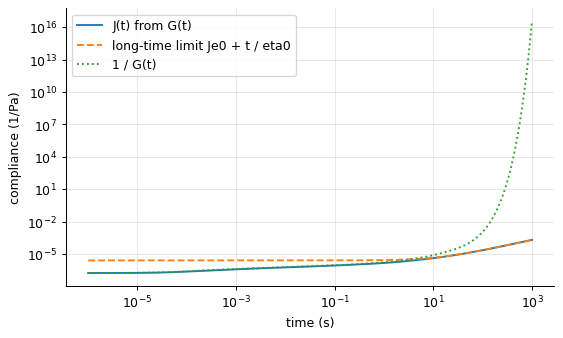

J(t) G(t) <= 1 everywhere: True;  eta0 = 5.06e+06 Pa s, Je0 = 2.48e-06 1/Pa


In [5]:
g_ps = np.array([2.7e6, 1.08e6, 6.3e5, 5.4e5, 4.95e5, 3.6e5, 1.35e5])
tau_ps = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1.0, 5.0, 20.0])
G_t = lambda s: ve.relaxation_modulus(g_ps, tau_ps, s)
tc = np.r_[0.0, np.logspace(-6, 3, 2500)]
Jc = ve.creep_from_relaxation(G_t, tc)
eta0, Je0 = ve.zero_shear_viscosity(g_ps, tau_ps), ve.steady_state_compliance(g_ps, tau_ps)
plt.loglog(tc[1:], Jc[1:], label="J(t) from G(t)")
plt.loglog(tc[1:], Je0 + tc[1:] / eta0, "--", label="long-time limit Je0 + t / eta0")
plt.loglog(tc[1:], 1 / G_t(tc[1:]), ":", label="1 / G(t)")
plt.xlabel("time (s)"); plt.ylabel("compliance (1/Pa)"); plt.legend(); plt.show()
print(f"J(t) G(t) <= 1 everywhere: {np.all(Jc[1:] * G_t(tc[1:]) <= 1 + 1e-9)};  eta0 = {eta0:.3g} Pa s, Je0 = {Je0:.3g} 1/Pa")

At long times the melt creeps like a liquid with the zero-shear viscosity plus a recoverable elastic part,
the steady-state compliance $J_e^0$ - the quantity behind die swell and recoil. $J(t)$ is not simply $1/G(t)$:
the two are linked by a convolution, and $J(t)\,G(t) \le 1$ always.

## Inside the algorithm: Boltzmann superposition by hand
For a strain applied in steps, the stress is the sum of the relaxation responses of all steps so far,
$\sigma(t) = \sum_k \Delta\gamma_k\,G(t - t_k)$. A strain of 0.1 applied at t = 0 and removed at t = 2 s:

In [6]:
G_mx = mx["relaxation"]
t_ = np.linspace(0, 5, 11)
by_hand = 0.1 * G_mx(t_) - 0.1 * np.where(t_ >= 2, G_mx(np.maximum(t_ - 2, 0)), 0.0)
strain_hist = np.where(t_ < 2, 0.1, 0.0)
library = ve.boltzmann_stress(G_mx, np.r_[0, 1e-9, 2 - 1e-9, 2 + 1e-9, 5], [0.1, 0.1, 0.1, 0.0, 0.0])
print("stress by hand at t = 0..5 s:", np.round(by_hand, 2))
print("stress just after removal (library, t = 2 s):", round(float(library[3]), 2), " by hand:", round(float(0.1*G_mx(2) - 0.1*G_mx(0)), 2))

stress by hand at t = 0..5 s: [100.    60.65  36.79  22.31 -86.47 -52.44 -31.81 -19.29 -11.7   -7.1
  -4.3 ]
stress just after removal (library, t = 2 s): -86.47  by hand: -86.47


## Exercises
1. A cross-linked rubber must not creep indefinitely. Which model - Maxwell or standard linear solid - can describe it? Compare their creep compliances after 10 relaxation times.
2. What fraction of the dough's strain at 120 s has been recovered 180 s after unloading? Compare the measurement, the Burgers prediction and the limit for very long times.
3. **Implement it yourself:** fit a single Maxwell element to relaxation data by a straight line of $\ln G$ against $t$ (generate the data from `ve.maxwell(2000, 500)` with 2 % noise). How accurate are $G$ and $\tau$?